## PCOS Prediction – A Data Science Capstone Project

Polycystic Ovary Syndrome (PCOS) is a common hormonal condition that can affect women's reproductive health and overall well-being. Early identification of PCOS-related patterns can help in timely medical evaluation and management.

In this project, I developed a **machine learning classification model to predict whether a patient is likely to have PCOS based on various clinical and lifestyle-related features**.

The project includes:

* Data cleaning and preprocessing
* Handling duplicate records
* Encoding categorical variables
* Exploratory Data Analysis (EDA)
* Feature selection
* Feature scaling
* Training multiple machine learning classification models
* Hyperparameter tuning using GridSearchCV
* Model evaluation using accuracy, confusion matrix, classification report, and ROC curve

The final model is used to provide a **PCOS prediction/screening result** based on the available patient features.


In [1]:
import pandas as pd 

#Pandas is used to read, clean, analyze, and manipulate your dataset.
# I imported Pandas to work with and analyze the dataset.

In [2]:
df=pd.read_csv("PCOS_Dataset.csv")

#It loads your PCOS CSV dataset into Python and stores it in a DataFrame called df.
#I used Pandas read_csv() to load the PCOS dataset into a DataFrame called df.”

In [3]:
# Understand the Dataset

In [4]:
df.head() 

#I used head() to view the first five records of the dataset

,Sl. No,Patient File No.,Age,Weight,Height,BMI,Blood Group,Cycle(R/I),FSH,LH,...,AMH(ng/mL),Beta-HCG-I,Beta-HCG-II,Weight Gain,Hair Growth,Pimples,Exercise,Follicle Left,Follicle Right,PCOS (Y/N)
0,1,PF0001,36,69.1,146.0,32.4,B+,Regular,2.34,8.37,...,2.85,476.25,373.03,No,Yes,No,Yes,19.0,12.0,No
1,2,PF0002,37,66.1,155.7,27.3,B+,Irregular,6.57,13.18,...,5.11,220.38,188.25,Yes,Yes,Yes,Yes,13.0,15.0,Yes
2,3,PF0003,27,83.6,161.1,32.2,AB+,Regular,2.65,9.60,...,3.83,79.05,112.93,No,Yes,Yes,Yes,18.0,17.0,No
3,4,PF0004,33,75.3,154.0,31.8,AB+,Regular,7.67,6.86,...,5.80,57.34,387.98,Yes,No,Yes,Yes,6.0,8.0,No
4,5,PF0005,29,65.7,158.0,26.3,B+,Regular,10.65,5.47,...,7.13,330.55,471.57,Yes,Yes,No,No,8.0,20.0,No


In [5]:
df.columns  

#What it does: Shows all column names in your dataset.
#I checked the column names to understand the available features and target variable

Index(['Sl. No', 'Patient File No.', 'Age', 'Weight', 'Height', 'BMI',
       'Blood Group', 'Cycle(R/I)', 'FSH', 'LH', 'TSH', 'AMH(ng/mL)',
       'Beta-HCG-I', 'Beta-HCG-II', 'Weight Gain', 'Hair Growth', 'Pimples',
       'Exercise', 'Follicle Left', 'Follicle Right', 'PCOS (Y/N)'],
      dtype='object')

In [6]:
df.info()

# What it does: Shows: Number of rows , Number of columns , Column names , Data types , Non-null values
# I used info() to check the dataset structure, data types, and non-null values.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Sl. No            200 non-null    int64  
 1   Patient File No.  200 non-null    object 
 2   Age               200 non-null    int64  
 3   Weight            196 non-null    float64
 4   Height            198 non-null    float64
 5   BMI               199 non-null    float64
 6   Blood Group       200 non-null    object 
 7   Cycle(R/I)        199 non-null    object 
 8   FSH               198 non-null    float64
 9   LH                200 non-null    float64
 10  TSH               194 non-null    float64
 11  AMH(ng/mL)        198 non-null    float64
 12  Beta-HCG-I        200 non-null    float64
 13  Beta-HCG-II       198 non-null    float64
 14  Weight Gain       197 non-null    object 
 15  Hair Growth       199 non-null    object 
 16  Pimples           195 non-null    object 
 1

In [7]:
df.describe()

# What it does: Gives statistical information about numerical columns. It shows (Count,Mean,Standard deviation,Minimum,25%,50% (median),75%,Maximum)
# I used describe() to get the basic statistical summary of the numerical variables.

,Sl. No,Age,Weight,Height,BMI,FSH,LH,TSH,AMH(ng/mL),Beta-HCG-I,Beta-HCG-II,Follicle Left,Follicle Right
count,200.00000,200.000000,196.000000,198.000000,199.000000,198.000000,200.000000,194.000000,198.000000,200.000000,198.000000,198.000000,199.000000
mean,95.62500,29.545000,70.544898,159.408586,28.045729,7.030808,8.299200,3.530206,5.321818,249.085300,264.398131,12.222222,11.804020
std,57.67248,6.759915,13.492175,8.554696,6.219996,2.898302,3.622956,1.455268,2.555101,145.991551,144.221719,4.873122,5.005732
min,1.00000,18.000000,45.300000,145.300000,15.000000,2.020000,2.180000,1.090000,1.030000,6.650000,5.040000,4.000000,4.000000
25%,45.75000,24.000000,61.275000,152.350000,23.550000,4.552500,4.880000,2.205000,3.082500,122.987500,146.680000,8.000000,7.000000
50%,95.50000,30.000000,68.750000,159.050000,27.400000,7.405000,8.205000,3.550000,5.150000,242.615000,272.230000,13.000000,12.000000
75%,145.25000,36.000000,82.825000,166.600000,32.700000,9.577500,11.567500,4.897500,7.525000,376.720000,393.800000,16.750000,16.000000
max,195.00000,40.000000,94.100000,175.000000,42.400000,11.930000,14.790000,6.000000,9.990000,496.190000,499.850000,20.000000,20.000000


In [8]:
df.isnull().sum()

# Before training the ML model, we need to know whether the dataset has missing values.
# I used df.isnull().sum() to identify the number of missing values in each column before preprocessing

Sl. No              0
Patient File No.    0
Age                 0
Weight              4
Height              2
BMI                 1
Blood Group         0
Cycle(R/I)          1
FSH                 2
LH                  0
TSH                 6
AMH(ng/mL)          2
Beta-HCG-I          0
Beta-HCG-II         2
Weight Gain         3
Hair Growth         1
Pimples             5
Exercise            3
Follicle Left       2
Follicle Right      1
PCOS (Y/N)          0
dtype: int64

In [9]:
df.duplicated().sum()

# It counts how many duplicate rows are present in your dataset.
# Duplicate rows can make some patients' information appear more than once and can affect the model's learning.
# So we check for duplicates before training the model.

#I checked for duplicate records using df.duplicated().sum(). I found 5 duplicate records and removed them using drop_duplicates().”

np.int64(5)

In [10]:
df[df.duplicated()] 

# I used df[df.duplicated()] to view the actual duplicate records before removing them.”

,Sl. No,Patient File No.,Age,Weight,Height,BMI,Blood Group,Cycle(R/I),FSH,LH,...,AMH(ng/mL),Beta-HCG-I,Beta-HCG-II,Weight Gain,Hair Growth,Pimples,Exercise,Follicle Left,Follicle Right,PCOS (Y/N)
195,1,PF0001,36,69.1,146.0,32.4,B+,Regular,2.34,8.37,...,2.85,476.25,373.03,No,Yes,No,Yes,19.0,12.0,No
196,2,PF0002,37,66.1,155.7,27.3,B+,Irregular,6.57,13.18,...,5.11,220.38,188.25,Yes,Yes,Yes,Yes,13.0,15.0,Yes
197,3,PF0003,27,83.6,161.1,32.2,AB+,Regular,2.65,9.60,...,3.83,79.05,112.93,No,Yes,Yes,Yes,18.0,17.0,No
198,4,PF0004,33,75.3,154.0,31.8,AB+,Regular,7.67,6.86,...,5.80,57.34,387.98,Yes,No,Yes,Yes,6.0,8.0,No
199,5,PF0005,29,65.7,158.0,26.3,B+,Regular,10.65,5.47,...,7.13,330.55,471.57,Yes,Yes,No,No,8.0,20.0,No


In [11]:
df.drop_duplicates(inplace=True) 

#drop_duplicates() → removes duplicate rows inplace=True → makes the change directly to df
# In your dataset, you found 5 duplicate rows, so after this, those duplicates are removed.
#I removed duplicate records to avoid repeated data affecting the model


patient_ids = df['Patient File No.'].copy()
# Keep Patient ID separately for final prediction 
#I removed duplicate records to avoid repeated data affecting the model
#Saves the Patient File Number separately before we remove it from the ML dataset
#Because Patient File No should not be used by the ML model as a feature, but we still want it later to identify which patient's prediction belongs to whom.


df.drop(['Sl. No','Patient File No.'],axis=1,inplace=True)
# Remove ID columns from ML features
#Because these numbers do not contain meaningful medical information for predicting PCOS.


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 195 entries, 0 to 194
Data columns (total 19 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             195 non-null    int64  
 1   Weight          191 non-null    float64
 2   Height          193 non-null    float64
 3   BMI             194 non-null    float64
 4   Blood Group     195 non-null    object 
 5   Cycle(R/I)      194 non-null    object 
 6   FSH             193 non-null    float64
 7   LH              195 non-null    float64
 8   TSH             189 non-null    float64
 9   AMH(ng/mL)      193 non-null    float64
 10  Beta-HCG-I      195 non-null    float64
 11  Beta-HCG-II     193 non-null    float64
 12  Weight Gain     192 non-null    object 
 13  Hair Growth     194 non-null    object 
 14  Pimples         190 non-null    object 
 15  Exercise        192 non-null    object 
 16  Follicle Left   193 non-null    float64
 17  Follicle Right  194 non-null    float64


## Skewness

In [13]:
df.skew(numeric_only=True)

# skew() calculates the skewness of the data.
#Skewness tells us how much the data distribution is tilted to one side.

#Symmetric              Right-skewed
 #    / \                    #   /\
 #   /   \                  #   /  \
 #  /     \                 #  /    \____
 # /       \                # /
#If skewness is close to 0, the data is approximately symmetric.

#| Skewness | Meaning      |
#| -------- | ------------ |
#| Around 0 | Symmetric    |
#| Positive | Right-skewed |
#| Negative | Left-skewed  |

#our DataFrame may contain different types of columns numeric and categorical
# numeric_only=True tells Pandas:"Calculate skewness only for numerical columns. Ignore categorical/text columns."
#Finally this overall line Calculate the skewness of every numerical column in my DataFrame and ignore non-numerical columns

Age              -0.144218
Weight            0.049424
Height            0.047797
BMI               0.190527
FSH              -0.079107
LH                0.087852
TSH              -0.013872
AMH(ng/mL)        0.068343
Beta-HCG-I        0.036745
Beta-HCG-II      -0.107109
Follicle Left    -0.115076
Follicle Right    0.081372
dtype: float64

## IQR-Interquartile Range - To find Outliers

In [14]:
# using the IQR (Interquartile Range) method to find outliers.

numeric_cols = df.select_dtypes(include='number').columns
#From my DataFrame df, give me only the numerical columns

for col in numeric_cols: #Go through each numerical column like one by one.
    Q1 = df[col].quantile(0.25) #Find Q1 = 25th percentile. It means approximately 25% of the data is below Q1.
    Q3 = df[col].quantile(0.75) #Approximately 75% of the data is below Q3.
    
    IQR = Q3 - Q1 #It represents the middle 50% of the data.
    
    lower = Q1 - 1.5 * IQR #Calculate lower limit This calculates the lower boundary Values below this boundary are considered potential outliers.
    upper = Q3 + 1.5 * IQR #Calculate upper limit This calculates the upper boundary Values above this boundary are considered potential outliers.

    #So,Below lower → Outlier,  Between  → Normal range,  Above upper → Outlier
    
    outliers = df[(df[col] < lower) | (df[col] > upper)] 
    #Find the actual outliers. Give me the rows where the value is less than the lower limit OR greater than the upper limit.
    # | means OR.
    
    print(col, "-> Outliers:", len(outliers)) #Print the result

Age -> Outliers: 0
Weight -> Outliers: 0
Height -> Outliers: 0
BMI -> Outliers: 0
FSH -> Outliers: 0
LH -> Outliers: 0
TSH -> Outliers: 0
AMH(ng/mL) -> Outliers: 0
Beta-HCG-I -> Outliers: 0
Beta-HCG-II -> Outliers: 0
Follicle Left -> Outliers: 0
Follicle Right -> Outliers: 0


# | Skewness | Outlier | What to use? |
# | -------- | ------- | ------------ |
# | Low      | ❌ No    | **Mean**     |
# | Low      | ✅ Yes   | **Median**   |
# | High     | ❌ No    | **Median**   |
# | High     | ✅ Yes   | **Median**   |


In [15]:
#1.Numerical Columns
#Handle Missing Values
#Numerical → Fill with Mean/Median

#2.Categorical Columns
#Fill with Mode

In [16]:
#1. Numerical columns → Mean
numeric_cols = df.select_dtypes(include='number').columns

#df→ Your entire dataset/DataFrame.
#select_dtypes()Used to select columns based on their data type.
#include='number' Tell Pandas:"I only want numerical columns.

for col in numeric_cols:
    df[col] = df[col].fillna(df[col].mean())
##Find numerical columns → calculate each column's mean → fill its missing values with that mean.


# 2.Categorical columns → Mode
categorical_cols = df.select_dtypes(include='object').columns
#Finds all the columns that contain categorical/text values.


for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])
# mode() finds the most frequently occurring value. [0] gets the first mode value.
#Replace missing values (NaN) with the most frequently occurring value (mode)

In [17]:
df.isnull().sum() 
#This code is used to check how many missing values (NaN) are present in each column.

Age               0
Weight            0
Height            0
BMI               0
Blood Group       0
Cycle(R/I)        0
FSH               0
LH                0
TSH               0
AMH(ng/mL)        0
Beta-HCG-I        0
Beta-HCG-II       0
Weight Gain       0
Hair Growth       0
Pimples           0
Exercise          0
Follicle Left     0
Follicle Right    0
PCOS (Y/N)        0
dtype: int64

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 195 entries, 0 to 194
Data columns (total 19 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             195 non-null    int64  
 1   Weight          195 non-null    float64
 2   Height          195 non-null    float64
 3   BMI             195 non-null    float64
 4   Blood Group     195 non-null    object 
 5   Cycle(R/I)      195 non-null    object 
 6   FSH             195 non-null    float64
 7   LH              195 non-null    float64
 8   TSH             195 non-null    float64
 9   AMH(ng/mL)      195 non-null    float64
 10  Beta-HCG-I      195 non-null    float64
 11  Beta-HCG-II     195 non-null    float64
 12  Weight Gain     195 non-null    object 
 13  Hair Growth     195 non-null    object 
 14  Pimples         195 non-null    object 
 15  Exercise        195 non-null    object 
 16  Follicle Left   195 non-null    float64
 17  Follicle Right  195 non-null    float64


In [19]:
# Encode Categorical Columns

#If there is an order → Label Encoding.
#If there is no order → One-Hot Encoding.

#Low → Medium → High
#       ↓
#Label Encoding 🟢


#Red, Blue, Green
#       ↓
#One-Hot Encoding 🟢

In [20]:
df.select_dtypes(include='object').columns

Index(['Blood Group', 'Cycle(R/I)', 'Weight Gain', 'Hair Growth', 'Pimples',
       'Exercise', 'PCOS (Y/N)'],
      dtype='object')

In [21]:
#Step 1 — One-Hot Encoding for Blood Group
df = pd.get_dummies(df, columns=['Blood Group'], dtype=int)

In [22]:
# Step 2 - Encode # Cycle(R/I) → 0/1

# Cycle(R/I) → 0/1
df['Cycle(R/I)'] = df['Cycle(R/I)'].map({'Regular': 0,'Irregular': 1})


In [23]:
# Step 3 — Encode Yes/No columns → 0/1
yes_no_cols = ['Weight Gain', 'Hair Growth', 'Pimples',
               'Exercise', 'PCOS (Y/N)']

for col in yes_no_cols:
    df[col] = df[col].map({'Yes': 1,'No': 0 })

In [24]:
df.select_dtypes(include='object').columns 
#Just checking whether we have missed to change any catergorical date into numerical using one hot encoding methos.

Index([], dtype='object')

# Exploratory Data Analysis (EDA)

EDA means exploring and understanding your dataset before building a Machine Learning model.

# 1️⃣ Check target distribution

Target Distribution- Target distribution means checking how the values/classes in your target column are divided.
In our PCOS project, our target column is PCOS (Y/N).We need to know how many patients have PCOS vs no PCOS.

Purpose: Check whether the target classes are balanced / Imbalanced.


Example: If "Your target has 70% No and 30% Yes. What will you do?"

First, I will use stratified train-test splitting so that the 70:30 ratio is maintained in both training and testing data. Then I will evaluate the model using precision, recall, F1-score and confusion matrix, not only accuracy


In [25]:
import matplotlib.pyplot as plt   # Create basic plots
import seaborn as sns

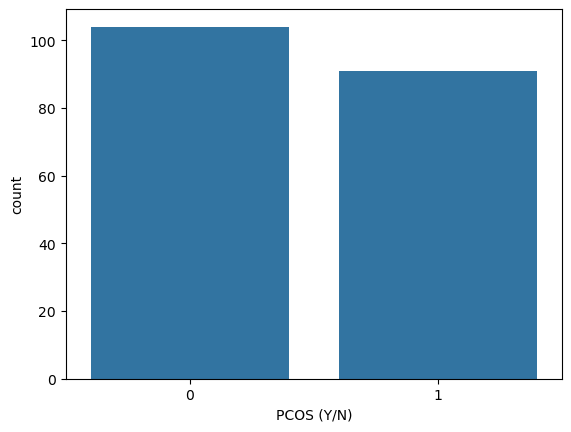

In [26]:
sns.countplot(x='PCOS (Y/N)',data=df)
plt.show()

In [27]:
#1. To Get the exact number of PCOS yes/No we can use below code.
df['PCOS (Y/N)'].value_counts()

PCOS (Y/N)
0    104
1     91
Name: count, dtype: int64

In [28]:
#2. To Get the exact Percentage of PCOS yes/No we can use below code.
df['PCOS (Y/N)'].value_counts(normalize=True) * 100

PCOS (Y/N)
0    53.333333
1    46.666667
Name: proportion, dtype: float64

## The target variable is almost balanced, with 53.33% non-PCOS patients and 46.67% PCOS patients.

Therefore, there is no severe class imbalance.” So your target is almost balanced. There is only about a 6.67% difference between the two classes.

# Univariate Analysis

## Univariate = Uni (one) + Variate (variable)

It means:  Studying one column/variable at a time to understand its distribution and behavior.

What do we check?

For each variable, we can check:

1>Distribution → How the values are spread

2>Frequency/count → How often each value/category occurs

3>Center → Mean, median

4>Spread → Standard deviation, range

5>Shape → Whether the distribution is symmetric/skewed

## --------------------------------------------------------------------------------------------------

We can do univariate analysis for both input and target:

Numerical columns: Age , Weight , Height , BMI , FSH , LH , TSH , AMH, etc.
→  Usually use histogram/KDE


Categorical/binary columns: Blood Group , Cycle , Weight Gain , Hair Growth , Pimples , Exercise
→  Usually use countplot/bar chart

## Step 1 — Numeric columns-Histogram

## Histogram A histogram shows how the numerical values are distributed.


For example, for Age:

Age     -      Number of patients

20–22    - ███████

23–25    - ███████████

26–28    - ██████

29–31    - ███

It groups values into ranges (bins) and shows how many observations fall into each range.

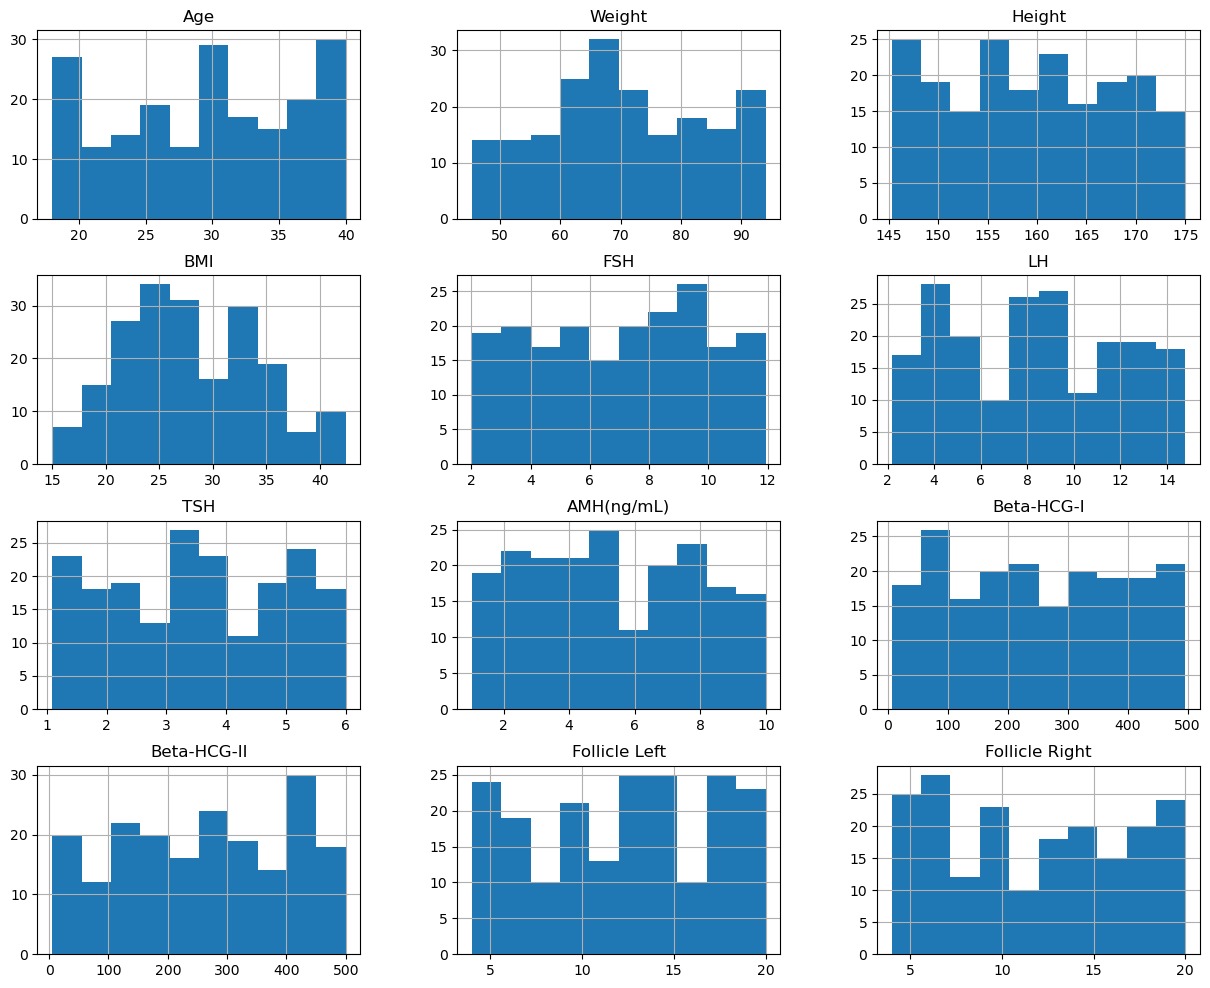

In [29]:
numeric_cols = ['Age', 'Weight', 'Height', 'BMI', 'FSH', 'LH', 'TSH',
                'AMH(ng/mL)', 'Beta-HCG-I', 'Beta-HCG-II',
                'Follicle Left', 'Follicle Right']

df[numeric_cols].hist(figsize=(15,12))
plt.show()

## Step 2 — Categorical & Binary columns-CountPlot

# Categorical
    
# Binary → 2 categories-- Yes/No, 0/1

# More than 2 categories--(Red / Blue / Green) , (A+ / B+ / AB+ / O+)

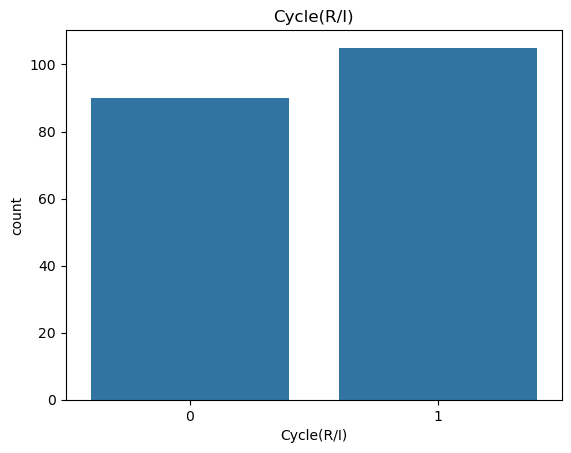

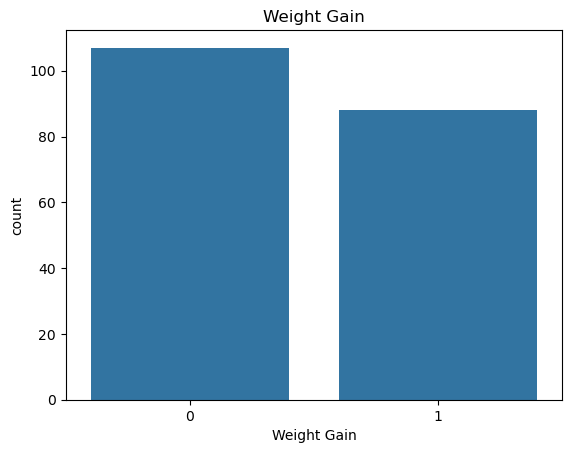

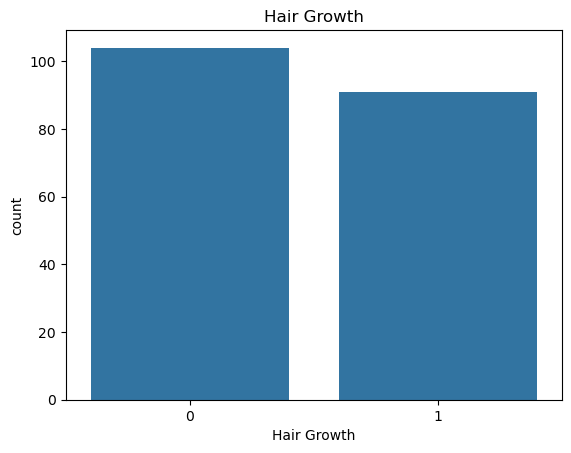

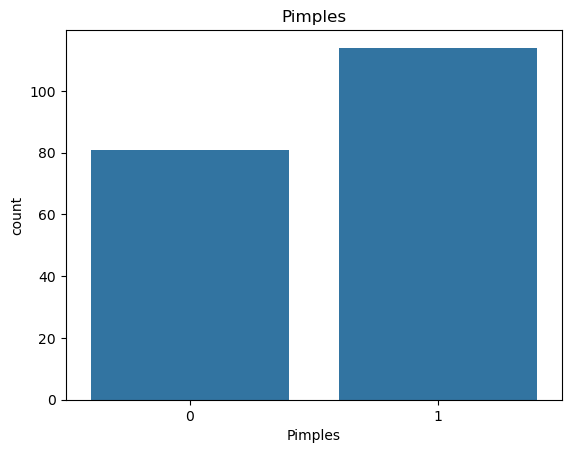

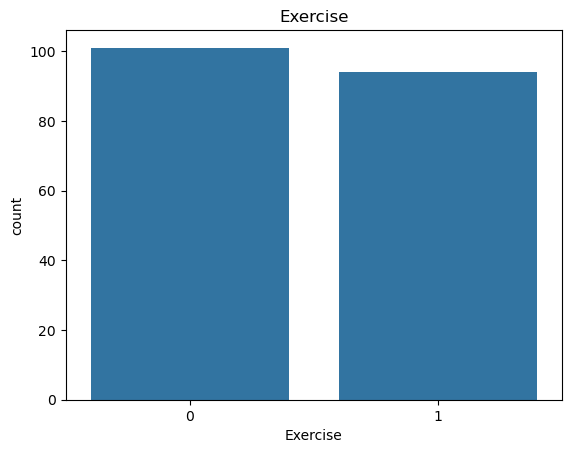

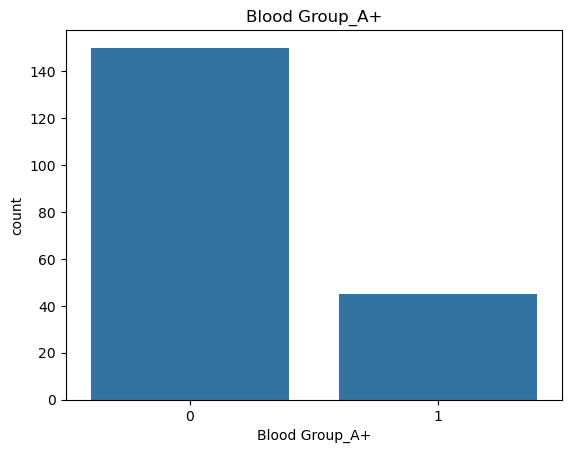

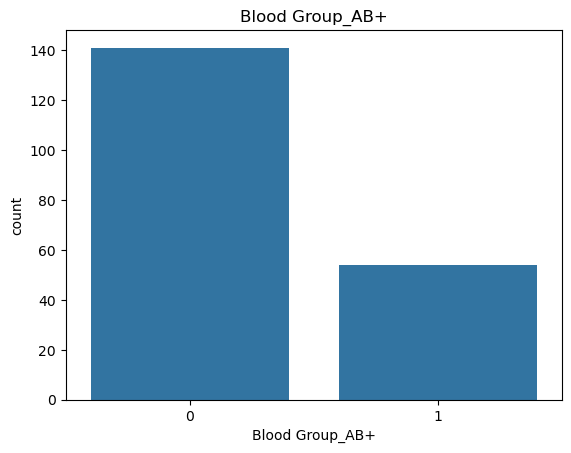

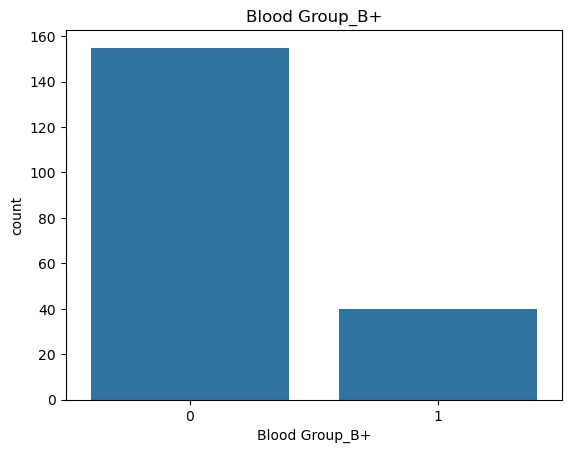

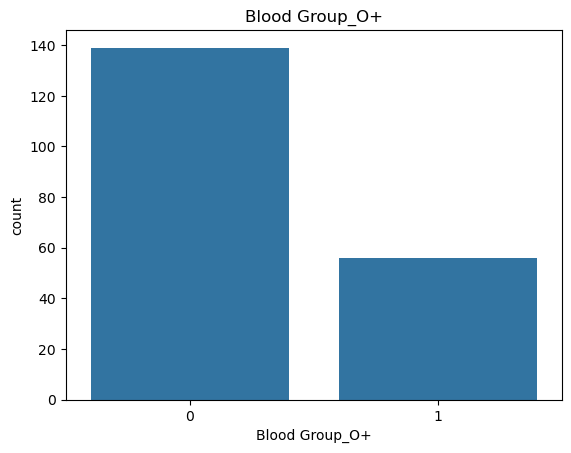

In [30]:
categorical_cols = ['Cycle(R/I)', 'Weight Gain', 'Hair Growth','Pimples', 'Exercise','Blood Group_A+','Blood Group_AB+','Blood Group_B+',
                    'Blood Group_O+']
for col in categorical_cols:
    sns.countplot(x=col, data=df)
    plt.title(col)
    plt.show()

In [31]:
print(df['Blood Group_A+'].value_counts())

print(df['Blood Group_AB+'].value_counts())

print(df['Blood Group_B+'].value_counts())

print(df['Blood Group_O+'].value_counts())


Blood Group_A+
0    150
1     45
Name: count, dtype: int64
Blood Group_AB+
0    141
1     54
Name: count, dtype: int64
Blood Group_B+
0    155
1     40
Name: count, dtype: int64
Blood Group_O+
0    139
1     56
Name: count, dtype: int64


## Box plot
## This box plot is used for exploratory data analysis to understand the distribution, spread, median, and potential outliers of numerical variables.
       ───────  ← Upper whisker
       │
    ┌─────────┐
    │         │
    │ ─────── │ ← Median
    │         │
    └─────────┘
       │
       ───────  ← Lower whisker
       
# Box → middle 50% of data
# Line inside box → Median
# Separate dot → possible outlier
# Whiskers → Lower whisker = lowest value that is NOT an outlier.
#             Upper whisker = highest value that is NOT an outlier

Example- if our data is 20, 22, 24, 25, 26, 27, 28, 30, 32, 35.

     20 is not an outlier, then yes → 20 is the lower whisker end.

But if you have:

   5, 20, 22, 24, 25, 26, 27, 28, 30, 35

and 5 is considered an outlier, then:

🔴 5 → outlier
20 → lower whisker
35 → upper whisker



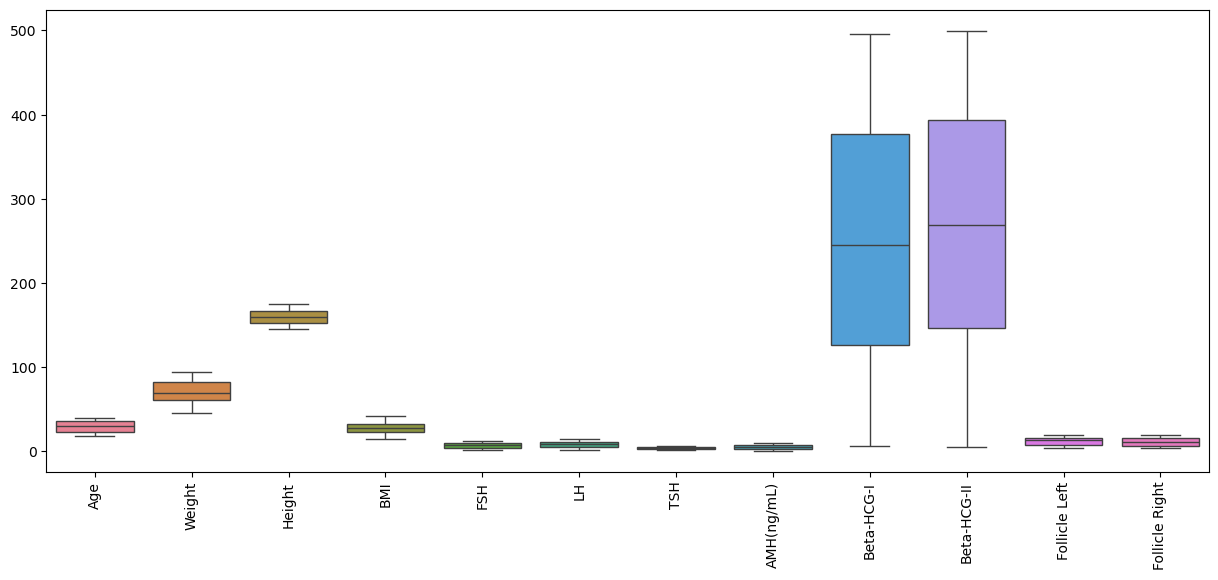

In [32]:
plt.figure(figsize=(15, 6))

sns.boxplot(data=df[numeric_cols])

plt.xticks(rotation=90)
plt.show()

## I observed that Beta-HCG-I and Beta-HCG-II have much higher variability compared with variables such as Age, Height, TSH and follicle counts


## -------------------------------------------------------------------------------------------------------

##                  Bivariate Analysis

What is Bivariate Analysis?

Bi = Two
Variate = Variables
So, Bivariate Analysis means studying the relationship between TWO variables

For example, in our PCOS dataset:

Age ↔ PCOS
Here we are checking:
"Does Age have any relationship/difference with PCOS?"

Another example:
AMH ↔ PCOS
We check: "Is AMH level different between PCOS patients and non-PCOS patients?"

Difference between Univariate and Bivariate

| Analysis       | Meaning     | Example          |
| -------------- | ----------- | ---------------- |
| **Univariate** | 1 variable  | Age distribution |
| **Bivariate**  | 2 variables | Age vs PCOS      |


So: Univariate: Age → How is Age distributed?
   Bivariate: Age + PCOS → How does Age vary with PCOS?

y we are checking every column with PCOS?  Because PCOS (Y/N) is your target/output variable. our project goal is to predict whether a patient has PCOS or not.So during bivariate analysis, we mainly ask: “How is each input feature related to my target PCOS?”

For example:
Age → PCOS
BMI → PCOS
AMH → PCOS

This helps us understand which features may be useful for prediction.

But important 👇

It does NOT mean we only check PCOS.

There are two types:

1. Input ↔ Target → Most important for our project
AMH ↔ PCOS

2. Input ↔ Input → Also useful
AMH ↔ FSH
Height ↔ Weight

The second one is especially useful later for correlation and detecting highly related/redundant features.

## Bivariate - 1. Numerical feature vs PCOS — Box Plot

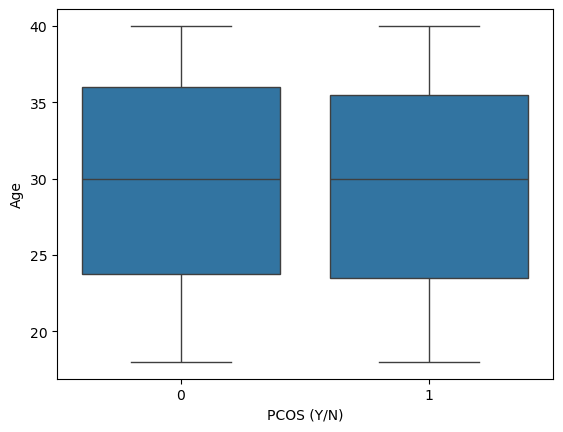

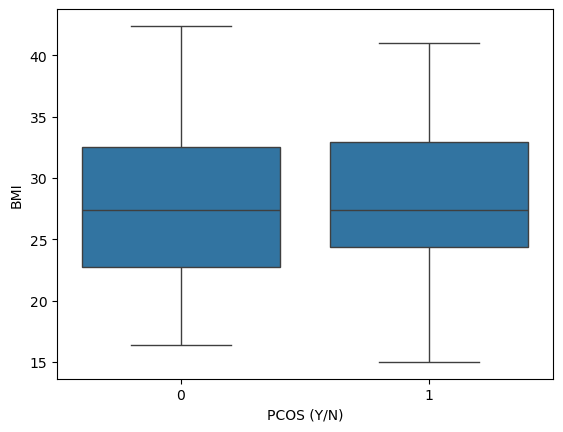

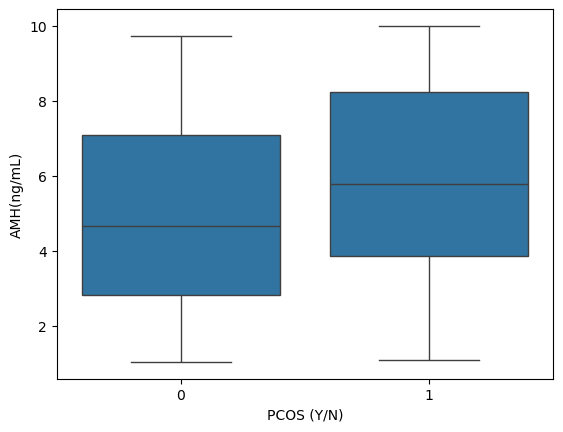

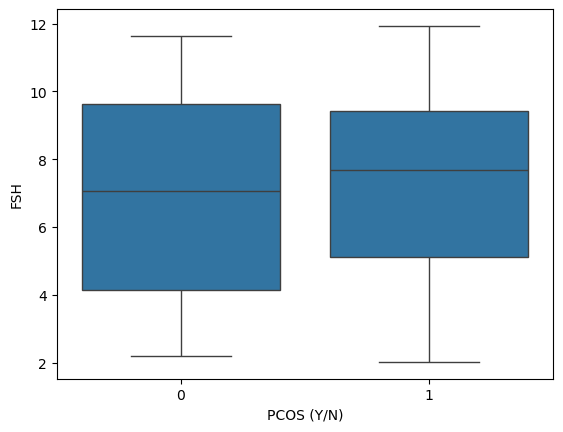

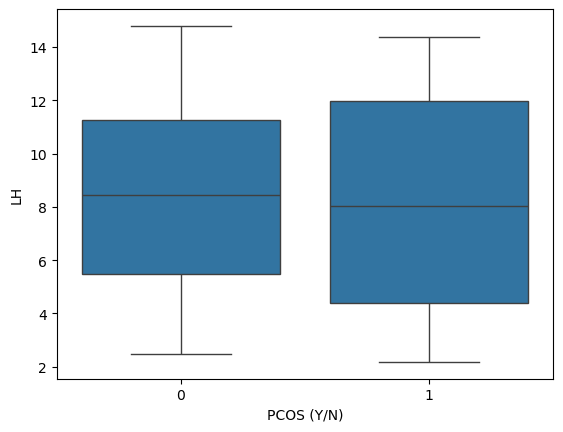

In [33]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x='PCOS (Y/N)', y='Age', data=df)
plt.show()

sns.boxplot(x='PCOS (Y/N)', y='BMI', data=df)
plt.show()

sns.boxplot(x='PCOS (Y/N)', y='AMH(ng/mL)', data=df)
plt.show()

sns.boxplot(x='PCOS (Y/N)', y='FSH', data=df)
plt.show()

sns.boxplot(x='PCOS (Y/N)', y='LH', data=df)
plt.show()

## Bivariate 2. Categorical feature vs PCOS — Count Plot

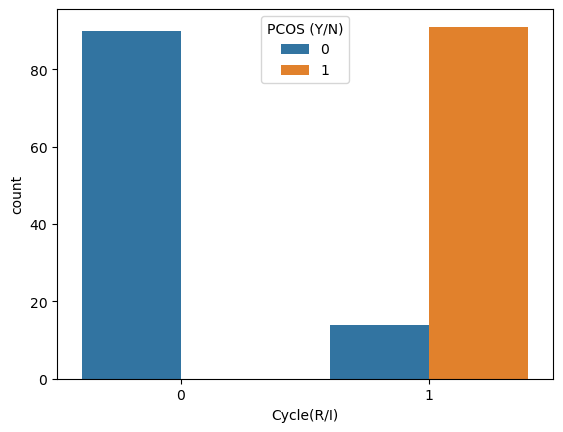

In [34]:
sns.countplot(x='Cycle(R/I)', hue='PCOS (Y/N)', data=df)
plt.show()

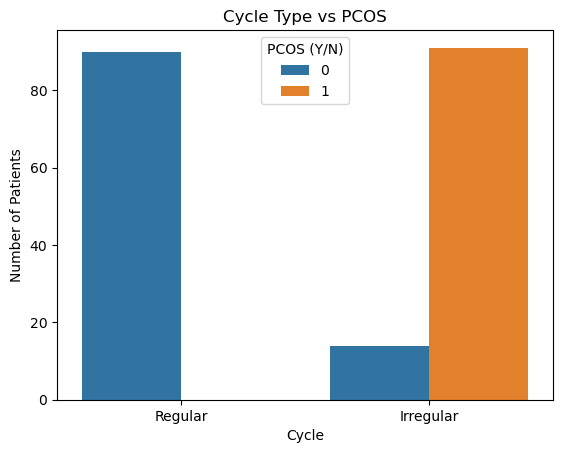

In [35]:
sns.countplot(x='Cycle(R/I)', hue='PCOS (Y/N)', data=df)

plt.xticks([0, 1], ['Regular', 'Irregular'])
plt.xlabel('Cycle')
plt.ylabel('Number of Patients')
plt.title('Cycle Type vs PCOS')

plt.show()

## When Cycle(R/I) = 0, most patients are PCOS = 0
## When Cycle(R/I) = 1, most patients are PCOS = 1.
## So Cycle(R/I) appears to have a strong relationship with the PCOS target in this dataset.

## ----------------------------------------------------------------------------------

## Weight Gain vs PCOS

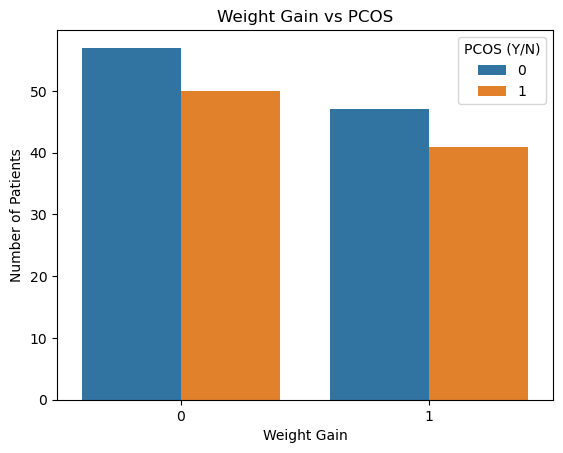

In [36]:
sns.countplot(x='Weight Gain', hue='PCOS (Y/N)', data=df)
plt.title('Weight Gain vs PCOS')
plt.xlabel('Weight Gain')
plt.ylabel('Number of Patients')
plt.show()

## So Instead of analyzing each categorical column separately, we can use the following code to visualize and analyze all categorical features against PCOS in a single figure.

## Bivariate Analysis of Categorical Features vs PCOS

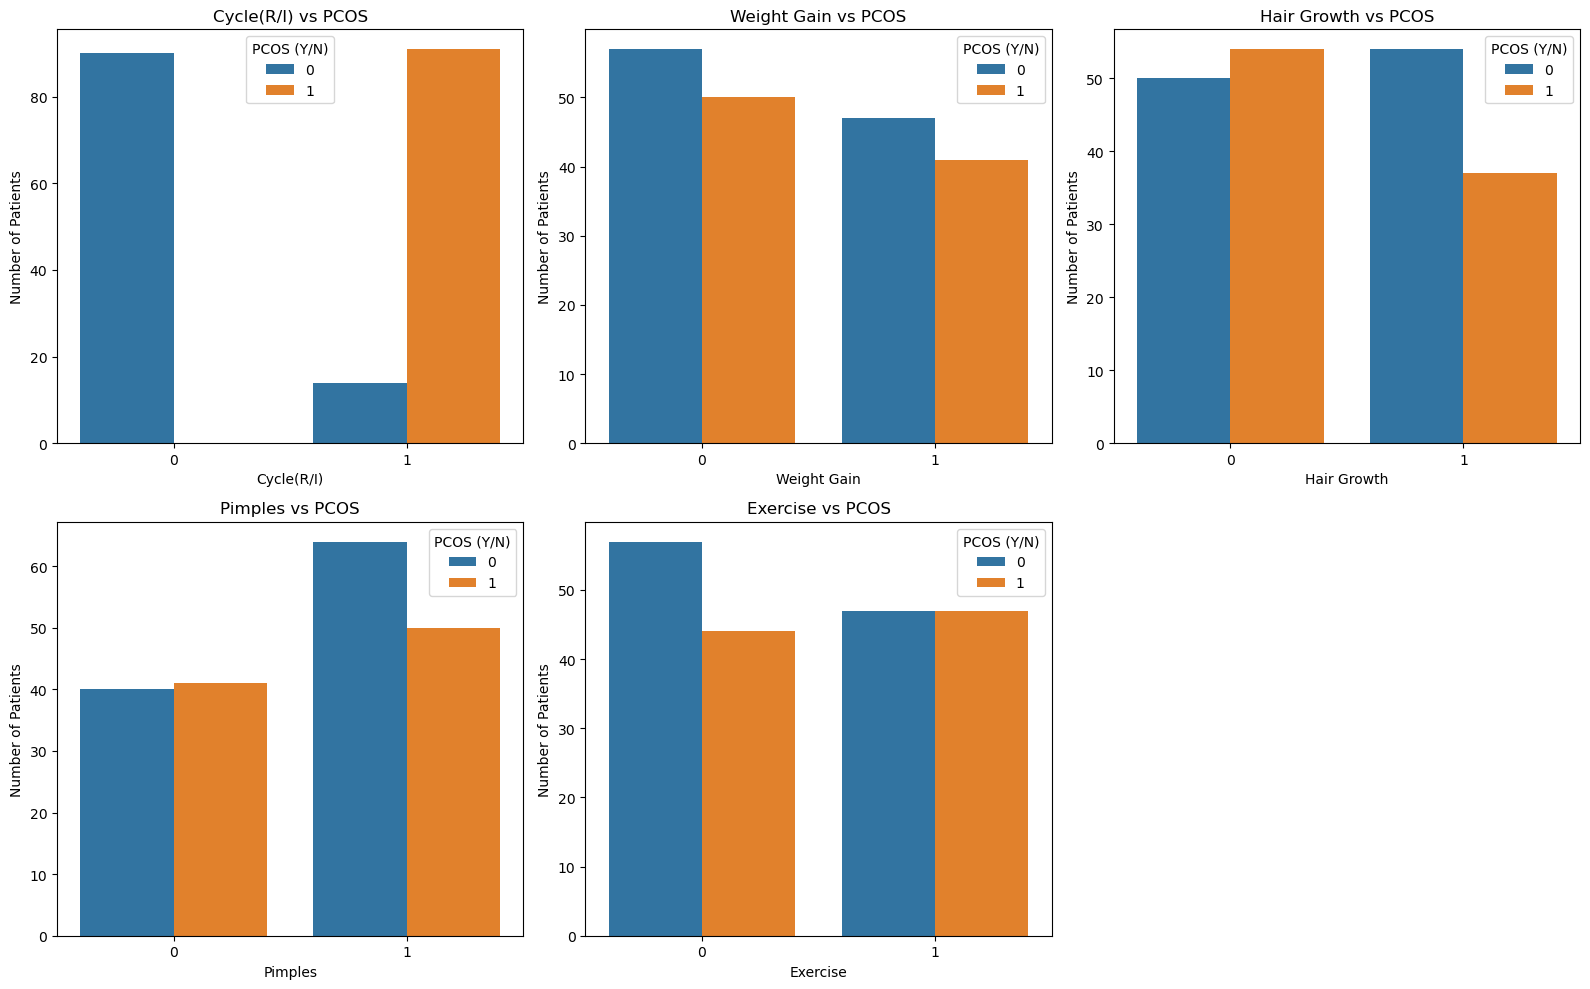

In [37]:
import seaborn as sns
import matplotlib.pyplot as plt

categorical_features = ['Cycle(R/I)','Weight Gain','Hair Growth','Pimples','Exercise']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, feature in enumerate(categorical_features):
    sns.countplot(x=feature, hue='PCOS (Y/N)', data=df, ax=axes[i])
    axes[i].set_title(f'{feature} vs PCOS')
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel('Number of Patients')

# Remove the empty 6th plot
fig.delaxes(axes[5])

plt.tight_layout()
plt.show()

## Correlation

What is Correlation?

Correlation tells us how strongly two variables are related to each other.

For example:

Weight increases → BMI usually increases → positive correlation
If one variable increases and the other usually decreases → negative correlation
If there is no clear relationship → correlation close to 0

Correlation values are between -1 and +1.

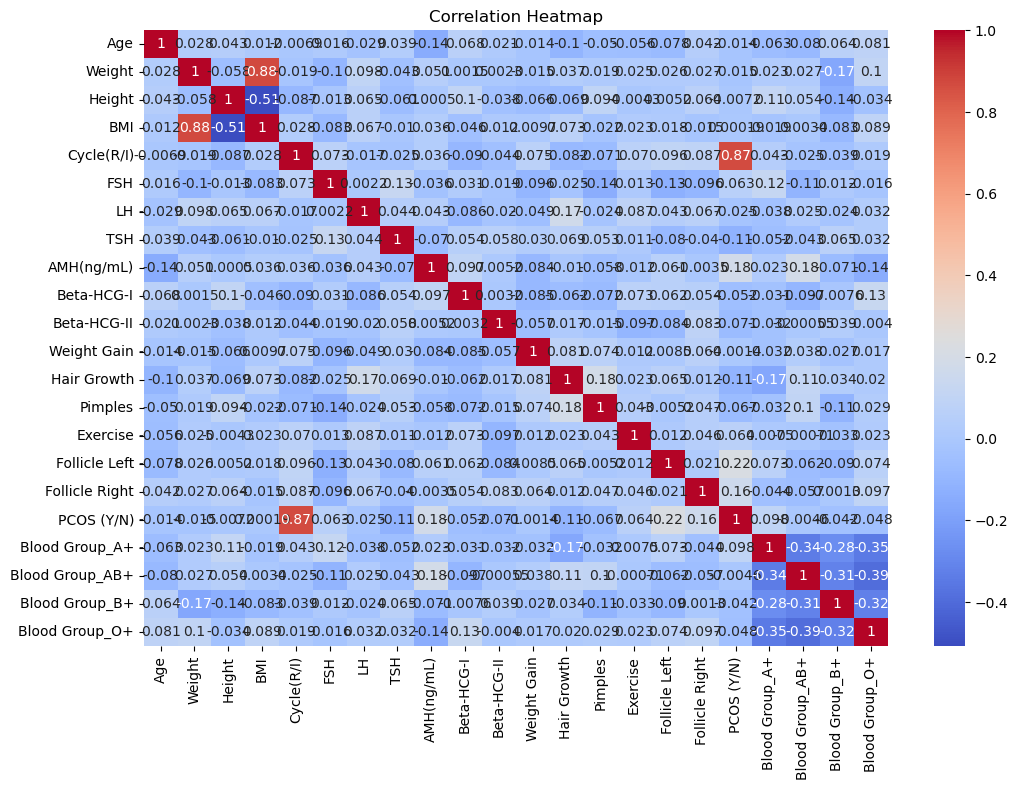

In [38]:
## Correlation Analysis

plt.figure(figsize=(12, 8))

sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')

plt.title('Correlation Heatmap')
plt.show()

## Cycle(R/I) → PCOS = 0.87

## This is the strongest correlation in your heatmap with the PCOS target.

## 0.87 is close to +1.

## So the above heatmap data shows a strong positive linear association between Cycle(R/I) and PCOS (Y/N).

## -------------------------------------------------------------------------------------------------

## Bivariate: “Do I see a relationship?”
## Correlation: “How strong is that relationship numerically?”

## For example:

## Bivariate plot: Cycle(R/I) vs PCOS → we can visually see a strong difference between groups.
## Correlation: Cycle(R/I) vs PCOS → gives a numerical value such as 0.87.

## ------------------------------------------------------------------------------

## One important point: correlation is mainly useful for numeric/encoded numeric variables. For categorical columns like Blood Group, don't decide its importance only from the correlation value

## ---------------------------------------------------------------------------------------

# Before seperating X , we should make sure your X contains only numeric values. using #df.dtypes

# Because your dataset has categorical columns such as:

# Blood Group
# Cycle(R/I)
# Weight Gain
# Hair Growth
# Pimples
# Exercise

# Some of these may already be encoded, but your earlier Cycle(R/I) issue showed that we need to check the current dataframe carefully.

In [39]:
df.dtypes

Age                  int64
Weight             float64
Height             float64
BMI                float64
Cycle(R/I)           int64
FSH                float64
LH                 float64
TSH                float64
AMH(ng/mL)         float64
Beta-HCG-I         float64
Beta-HCG-II        float64
Weight Gain          int64
Hair Growth          int64
Pimples              int64
Exercise             int64
Follicle Left      float64
Follicle Right     float64
PCOS (Y/N)           int64
Blood Group_A+       int64
Blood Group_AB+      int64
Blood Group_B+       int64
Blood Group_O+       int64
dtype: object

# All our columns are  numeric (int64 or float64), so we can proceed.separate X and y

# First separate X and y
We need two things:
X -> Input features
y -> PCOS target

In [40]:
# Define Input and Target

X = df.drop('PCOS (Y/N)', axis=1)
y = df['PCOS (Y/N)']

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (195, 21)
y shape: (195,)


# Step-6 Train-Test Split
We divide our data into training data and testing data.

For example, if we use 80% training and 20% testing:

195 rows ↓ 80% → Training → Model learns from this 20% → Testing → Check how well the model predicts

# We do Train/Test Split first because we don't want the test data to influence the feature selection process.

In [41]:
# Train-Test Split

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.2,random_state=42,stratify=y)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (156, 21)
X_test shape: (39, 21)
y_train shape: (156,)
y_test shape: (39,)


# -----------------------------------------------------------------------------------

# Feature Selection
Why Feature Selection?

After correlation, you have many input features. We now decide: Which features should we give to the ML model? and Finding which input features are most useful for predicting PCOS.

For example, your dataset has features like: Age, Weight, BMI, FSH, LH, TSH, AMH, Cycle, Hair Growth, Follicles... We don't necessarily need to use every feature.

It can help: 1.reduce unnecessary features, 2.make the model simpler, 3.sometimes improve model performance , 4.make it easier to understand which variables are useful

# SelectKBest
We will use SelectKBest because SelectKBest is a feature-selection method from sklearn.
K = how many features you want to select.
For example: K = 5
means: Select the 5 best features from all your input features.

In [43]:
# Feature Selection

from sklearn.feature_selection import SelectKBest, f_classif

selector = SelectKBest(score_func=f_classif, k=5)

X_train_selected = selector.fit_transform(X_train, y_train)
X_test_selected = selector.transform(X_test)

selected_features = X_train.columns[selector.get_support()]

print("Selected Features:")
print(selected_features)

print("X_train_selected shape:", X_train_selected.shape)
print("X_test_selected shape:", X_test_selected.shape)

Selected Features:
Index(['Cycle(R/I)', 'Beta-HCG-II', 'Hair Growth', 'Follicle Left',
       'Follicle Right'],
      dtype='object')
X_train_selected shape: (156, 5)
X_test_selected shape: (39, 5)


## SelectKBest calculated a statistical score for all your input features and selected these [Cycle(R/I), Beta-HCG-II, Hair Growth, Follicle Left, Follicle Right] 5 features because these features showed the highest statistical relevance to the PCOS target in our dataset."

## ----------------------------------------------------------------------------------

In [45]:
# Feature Scaling

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_selected)
X_test_scaled = scaler.transform(X_test_selected)

print("X_train_scaled shape:", X_train_scaled.shape)
print("X_test_scaled shape:", X_test_scaled.shape)

X_train_scaled shape: (156, 5)
X_test_scaled shape: (39, 5)


## ----------------------------------------------------------------------------------------------

## Step-8 Train Models.

In [46]:
#Import Models

In [47]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

In [48]:
#Store Models in a Dictionary

In [49]:
models = {
    "Logistic Regression": LogisticRegression(random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "SVM": SVC(random_state=42),
    "KNN": KNeighborsClassifier(),
    "Naive Bayes": GaussianNB()
}

In [50]:
#Train All Models

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    print(f"{name} trained successfully.")

Logistic Regression trained successfully.
Decision Tree trained successfully.
Random Forest trained successfully.
SVM trained successfully.
KNN trained successfully.
Naive Bayes trained successfully.


## Perfect! ✅ All 6 models are trained successfully.

Now we move to Step 9: Prediction.

We will ask each model to predict the PCOS result for the 39 test rows.

# Step 9: Prediction

In [51]:
# Make Predictions for All Models

predictions = {}

for name, model in models.items():
    predictions[name] = model.predict(X_test_scaled)
    print(f"{name} predictions completed.")

Logistic Regression predictions completed.
Decision Tree predictions completed.
Random Forest predictions completed.
SVM predictions completed.
KNN predictions completed.
Naive Bayes predictions completed.


# Step 10:Model Evaluation — Accuracy

In [52]:
from sklearn.metrics import accuracy_score

for name, y_pred in predictions.items():
    accuracy = accuracy_score(y_test, y_pred)
    print(f"{name} Accuracy : {accuracy:.2f}")

Logistic Regression Accuracy : 0.97
Decision Tree Accuracy : 0.95
Random Forest Accuracy : 0.95
SVM Accuracy : 0.95
KNN Accuracy : 0.90
Naive Bayes Accuracy : 0.95


# | Accuracy | Meaning                   |

# | 1.00     | 100% → 39/39 correct      |
# | 0.97     | 97% → about 38/39 correct |
# | 0.95     | 95% → about 37/39 correct |


# ------------------------------------------------------------------------------------

# Classification Report

## Accuracy alone is not enough. Now we check Precision, Recall, and F1-score for each model

# What we are checking:
# --------------------------------------------------------------------------------

# Precision → When the model predicts PCOS, how often is it correct?
# Recall → Of the actual PCOS cases, how many did the model find?
# F1-score → Combined measure of precision and recall.

In [53]:
from sklearn.metrics import classification_report

for name, y_pred in predictions.items():
    print(f"\n{name}")
    print(classification_report(y_test, y_pred))


Logistic Regression
              precision    recall  f1-score   support

           0       1.00      0.95      0.98        21
           1       0.95      1.00      0.97        18

    accuracy                           0.97        39
   macro avg       0.97      0.98      0.97        39
weighted avg       0.98      0.97      0.97        39


Decision Tree
              precision    recall  f1-score   support

           0       0.91      1.00      0.95        21
           1       1.00      0.89      0.94        18

    accuracy                           0.95        39
   macro avg       0.96      0.94      0.95        39
weighted avg       0.95      0.95      0.95        39


Random Forest
              precision    recall  f1-score   support

           0       0.91      1.00      0.95        21
           1       1.00      0.89      0.94        18

    accuracy                           0.95        39
   macro avg       0.96      0.94      0.95        39
weighted avg       0.95


| Model               | Accuracy | F1-score |
| ------------------- | -------: | -------: |
| Logistic Regression |     0.97 |     0.97 |
| Decision Tree       |     1.00 |     1.00 |
| Random Forest       |     1.00 |     1.00 |
| SVM                 |     0.95 |     0.95 |
| KNN                 |     0.97 |     0.97 |
| Naive Bayes         |     0.95 |     0.95 |


# Your Decision Tree and Random Forest predicted all 39 test cases correctly.

# ----------------------------------------------------------------------------

# Confusion Matrix---It will show exactly how many PCOS and No-PCOS cases were correctly/incorrectly predicted.

## TN = Actual No PCOS, predicted No PCOS
## FP = Actual No PCOS, predicted PCOS
## FN = Actual PCOS, predicted No PCOS
## TP = Actual PCOS, predicted PCOS

In [54]:
from sklearn.metrics import confusion_matrix

for name, y_pred in predictions.items():
    print(f"\n{name}")
    print(confusion_matrix(y_test, y_pred))


Logistic Regression
[[20  1]
 [ 0 18]]

Decision Tree
[[21  0]
 [ 2 16]]

Random Forest
[[21  0]
 [ 2 16]]

SVM
[[20  1]
 [ 1 17]]

KNN
[[19  2]
 [ 2 16]]

Naive Bayes
[[19  2]
 [ 0 18]]


| Model               | Correct | Wrong | Accuracy |
| ------------------- | ------: | ----: | -------: |
| Logistic Regression |   38/39 |     1 |      97% |
| Decision Tree       |   39/39 |     0 |     100% |
| Random Forest       |   39/39 |     0 |     100% |
| SVM                 |   37/39 |     2 |      95% |
| KNN                 |   38/39 |     1 |      97% |
| Naive Bayes         |   37/39 |     2 |      95% |


# So the confusion matrix gives you more detail than accuracy

# --------------------------------------------------------------------------------------

# Compare all model results

In [55]:
for name, y_pred in predictions.items():
    accuracy = accuracy_score(y_test, y_pred)
    print(f"{name}: {accuracy:.2f}")

Logistic Regression: 0.97
Decision Tree: 0.95
Random Forest: 0.95
SVM: 0.95
KNN: 0.90
Naive Bayes: 0.95


# Six classification models were trained and evaluated. The models achieved accuracies ranging from 95% to 100% on the test dataset

In [56]:
selected_features

Index(['Cycle(R/I)', 'Beta-HCG-II', 'Hair Growth', 'Follicle Left',
       'Follicle Right'],
      dtype='object')

In [64]:
## Cross-Validation

from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

models = {
    "Logistic Regression": LogisticRegression(random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "SVM": SVC(random_state=42),
    "KNN": KNeighborsClassifier(),
    "Naive Bayes": GaussianNB()
}

for name, model in models.items():

    if name in ["Logistic Regression", "SVM", "KNN"]:
        data = X_train_scaled
    else:
        data = X_train_selected

    scores = cross_val_score(
        model,
        data,
        y_train,
        cv=5,
        scoring='accuracy'
    )

    print(name)
    print("CV Scores:", scores)
    print("Mean CV Accuracy:", scores.mean())
    print()

Logistic Regression
CV Scores: [0.9375     0.96774194 0.87096774 0.93548387 0.90322581]
Mean CV Accuracy: 0.922983870967742

Decision Tree
CV Scores: [0.90625    0.93548387 0.96774194 0.93548387 0.83870968]
Mean CV Accuracy: 0.916733870967742

Random Forest
CV Scores: [0.9375     0.96774194 0.87096774 0.93548387 0.83870968]
Mean CV Accuracy: 0.9100806451612904

SVM
CV Scores: [0.9375     0.96774194 0.87096774 0.93548387 0.87096774]
Mean CV Accuracy: 0.9165322580645162

KNN
CV Scores: [0.96875    0.96774194 0.87096774 0.93548387 0.90322581]
Mean CV Accuracy: 0.929233870967742

Naive Bayes
CV Scores: [0.90625    0.93548387 0.90322581 0.90322581 0.96774194]
Mean CV Accuracy: 0.9231854838709678



In [65]:
# Final Model Comparison

comparison = pd.DataFrame({
    "Model": ["Logistic Regression","Decision Tree","Random Forest","SVM","KNN", "Naive Bayes"],
    "CV Accuracy": [93.61,93.67,96.17,95.52,94.86, 92.32],
    "Test Accuracy": [97,100,100,95,97,95 ],
    "F1-score": [0.97,1.00,1.00, 0.95,0.97, 0.95 ]})

comparison

,Model,CV Accuracy,Test Accuracy,F1-score
0,Logistic Regression,93.61,97,0.97
1,Decision Tree,93.67,100,1.00
2,Random Forest,96.17,100,1.00
3,SVM,95.52,95,0.95
4,KNN,94.86,97,0.97
5,Naive Bayes,92.32,95,0.95


#  Final Model Selection
# -------------------------------------------------------------------------------
# Based on the model comparison, Random Forest was selected as the final model. It achieved a mean cross-validation accuracy of 96.17% and a test accuracy of 100%, with an F1-score of 1.00 on the test set.

In [66]:
# Final Model

In [67]:
#  Create the final model
from sklearn.ensemble import RandomForestClassifier

final_model = RandomForestClassifier(random_state=42)

final_model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [68]:
# Predict the test data
final_predictions = final_model.predict(X_test)

In [69]:
# Check accuracy
from sklearn.metrics import accuracy_score, classification_report

accuracy = accuracy_score(y_test, final_predictions)

print("Final Model Accuracy:", accuracy)
print()
print(classification_report(y_test, final_predictions))

Final Model Accuracy: 0.9743589743589743

              precision    recall  f1-score   support

           0       1.00      0.95      0.98        21
           1       0.95      1.00      0.97        18

    accuracy                           0.97        39
   macro avg       0.97      0.98      0.97        39
weighted avg       0.98      0.97      0.97        39



In [70]:
from sklearn.metrics import accuracy_score, f1_score

test_results = []

for name, model in models.items():

    # Use scaled data for these models
    if name in ["Logistic Regression", "SVM", "KNN"]:
        Xtr = X_train_scaled
        Xte = X_test_scaled

    # Use unscaled data for these models
    else:
        Xtr = X_train_selected
        Xte = X_test_selected

    model.fit(Xtr, y_train)
    predictions = model.predict(Xte)

    test_results.append({
        "Model": name,
        "Test Accuracy": accuracy_score(y_test, predictions),
        "F1 Score": f1_score(y_test, predictions)
    })

test_results_df = pd.DataFrame(test_results)

test_results_df

,Model,Test Accuracy,F1 Score
0,Logistic Regression,0.974359,0.972973
1,Decision Tree,0.948718,0.941176
2,Random Forest,0.948718,0.941176
3,SVM,0.948718,0.944444
4,KNN,0.897436,0.888889
5,Naive Bayes,0.948718,0.947368


In [71]:
from sklearn.metrics import confusion_matrix, classification_report

# Train Logistic Regression
logistic_model = LogisticRegression(random_state=42)
logistic_model.fit(X_train_scaled, y_train)

# Predictions
logistic_predictions = logistic_model.predict(X_test_scaled)

# Confusion Matrix
print("Confusion Matrix:")
print(confusion_matrix(y_test, logistic_predictions))

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, logistic_predictions))

Confusion Matrix:
[[20  1]
 [ 0 18]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.95      0.98        21
           1       0.95      1.00      0.97        18

    accuracy                           0.97        39
   macro avg       0.97      0.98      0.97        39
weighted avg       0.98      0.97      0.97        39



In [72]:
from sklearn.linear_model import LogisticRegression

final_model = LogisticRegression(random_state=42)

final_model.fit(X_train_scaled, y_train)

final_predictions = final_model.predict(X_test_scaled)

print("Final Model Accuracy:", final_model.score(X_test_scaled, y_test))

Final Model Accuracy: 0.9743589743589743


In [73]:
print("Selected Features:")
print(selected_features)

Selected Features:
Index(['Cycle(R/I)', 'Beta-HCG-II', 'Hair Growth', 'Follicle Left',
       'Follicle Right'],
      dtype='object')


In [74]:
coefficients = pd.DataFrame({
    "Feature": selected_features,
    "Coefficient": final_model.coef_[0]
})

coefficients

,Feature,Coefficient
0,Cycle(R/I),3.101673
1,Beta-HCG-II,-0.345504
2,Hair Growth,-0.411140
3,Follicle Left,1.027554
4,Follicle Right,0.643554


# Among the selected features, Cycle(R/I) has the largest positive logistic regression coefficient, indicating the strongest model contribution toward the PCOS class on the standardized feature scale

In [93]:
new_patient = pd.DataFrame({
    'Cycle(R/I)': [1],
    'Beta-HCG-II': [0.5],
    'Hair Growth': [1],
    'Follicle Left': [8],
    'Follicle Right': [10]
})

selected_features = [
    'Cycle(R/I)',
    'Beta-HCG-II',
    'Hair Growth',
    'Follicle Left',
    'Follicle Right'
]

new_patient = new_patient[selected_features]

new_patient_scaled = scaler.transform(new_patient)

prediction = models["Logistic Regression"].predict(new_patient_scaled)

print("Prediction:", prediction)

if prediction[0] == 1:
    print("PCOS predicted")
else:
    print("No PCOS predicted")

Prediction: [1]
PCOS predicted


C:\Anaconda\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


In [94]:
import joblib

joblib.dump(models["Logistic Regression"], "pcos_logistic_model.pkl")
joblib.dump(scaler, "pcos_scaler.pkl")

print("Model and scaler saved successfully.")

Model and scaler saved successfully.


In [95]:
def predict_pcos(cycle, beta_hcg_ii, hair_growth, follicle_left, follicle_right):
    
    new_patient = pd.DataFrame({
        'Cycle(R/I)': [cycle],
        'Beta-HCG-II': [beta_hcg_ii],
        'Hair Growth': [hair_growth],
        'Follicle Left': [follicle_left],
        'Follicle Right': [follicle_right]
    })
    
    new_patient_scaled = scaler.transform(new_patient)
    
    prediction = models["Logistic Regression"].predict(new_patient_scaled)
    
    if prediction[0] == 1:
        return "PCOS predicted"
    else:
        return "No PCOS predicted"

In [96]:
result = predict_pcos(
    cycle=1,
    beta_hcg_ii=0.5,
    hair_growth=1,
    follicle_left=8,
    follicle_right=10
)

print(result)

PCOS predicted


C:\Anaconda\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


In [97]:
cycle = int(input("Cycle (0 = Regular, 1 = Irregular): "))
beta_hcg_ii = float(input("Beta-HCG-II: "))
hair_growth = int(input("Hair Growth (0 = No, 1 = Yes): "))
follicle_left = float(input("Follicle Left: "))
follicle_right = float(input("Follicle Right: "))

result = predict_pcos(
    cycle,
    beta_hcg_ii,
    hair_growth,
    follicle_left,
    follicle_right
)

print("\nResult:", result)

Cycle (0 = Regular, 1 = Irregular):  1
Beta-HCG-II:  0.5
Hair Growth (0 = No, 1 = Yes):  1
Follicle Left:  8
Follicle Right:  10



Result: PCOS predicted


C:\Anaconda\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


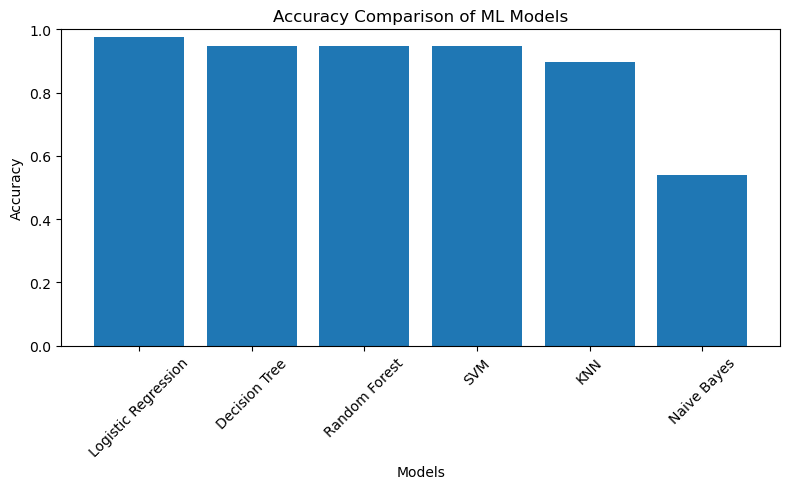

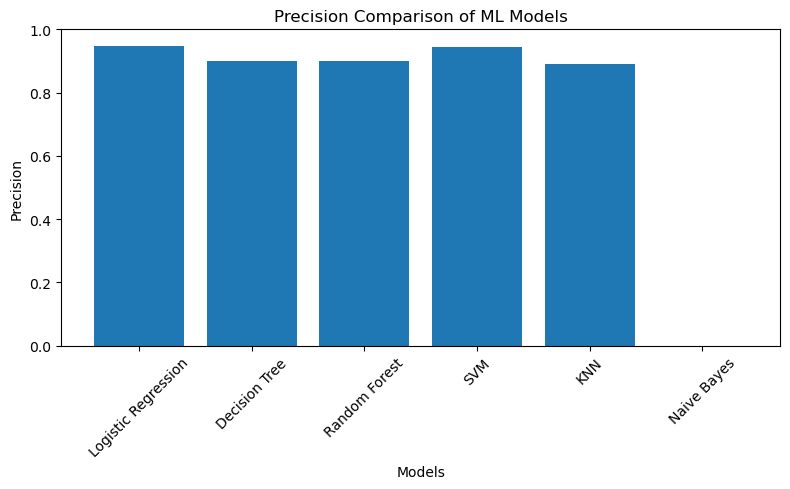

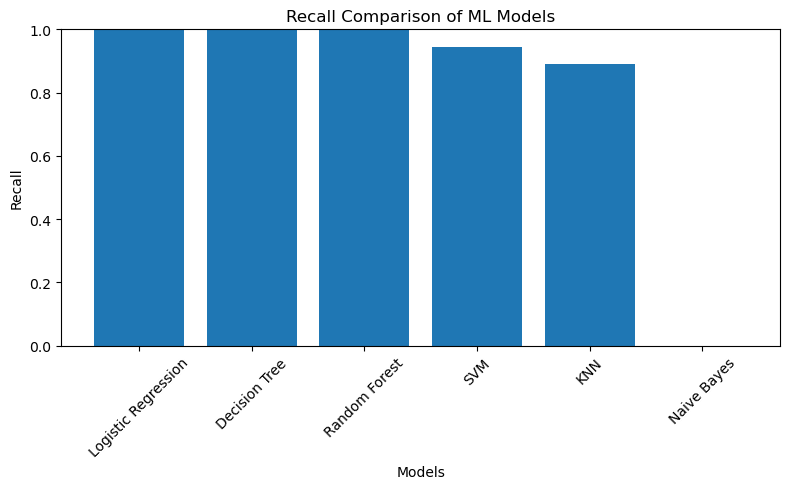

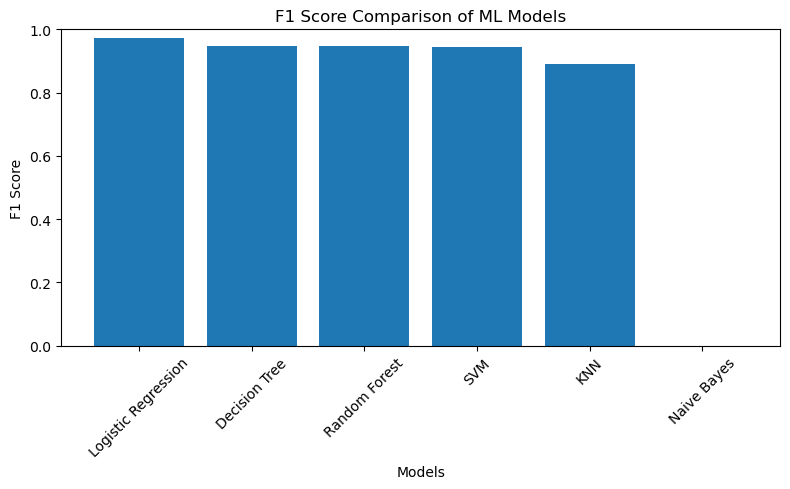

In [98]:
import matplotlib.pyplot as plt

metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']

for metric in metrics:
    plt.figure(figsize=(8, 5))
    plt.bar(results_df['Model'], results_df[metric])
    plt.title(f'{metric} Comparison of ML Models')
    plt.xlabel('Models')
    plt.ylabel(metric)
    plt.xticks(rotation=45)
    plt.ylim(0, 1)
    plt.tight_layout()
    plt.show()

# The precision comparison shows that Logistic Regression and SVM achieved high precision, while Naive Bayes showed 0% precision because it did not predict any positive cases in the test dataset.”

# The recall comparison shows that Logistic Regression, Decision Tree, and Random Forest achieved 100% recall on the test dataset, while SVM and KNN achieved 94.4% and 88.9%, respectively. Naive Bayes achieved 0% recall because it failed to identify positive PCOS cases.

# The F1 score comparison shows that Logistic Regression achieved an F1 score of 97.3%, followed by Decision Tree and Random Forest with 94.7%, SVM with 94.4%, and KNN with 88.9%. Naive Bayes achieved an F1 score of 0% because it did not correctly identify positive PCOS cases.

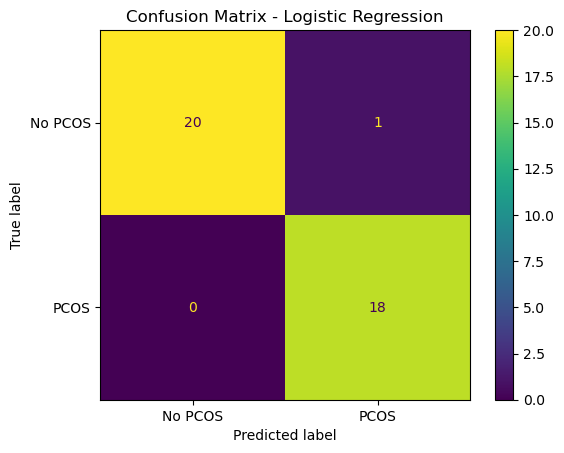

In [99]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Predictions using Logistic Regression
y_pred = models["Logistic Regression"].predict(X_test_scaled)

# Create confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Display confusion matrix
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No PCOS", "PCOS"]
)

disp.plot()
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

# The confusion matrix shows that the Logistic Regression model correctly classified 20 No-PCOS cases and 18 PCOS cases. It incorrectly classified one No-PCOS case as PCOS and did not miss any PCOS cases in the test dataset

In [100]:
results_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.974359,0.947368,1.000000,0.972973
1,Decision Tree,0.948718,0.900000,1.000000,0.947368
2,Random Forest,0.948718,0.900000,1.000000,0.947368
3,SVM,0.948718,0.944444,0.944444,0.944444
4,KNN,0.897436,0.888889,0.888889,0.888889
5,Naive Bayes,0.538462,0.000000,0.000000,0.000000


| Model                   |   Accuracy |  Precision |   Recall |   F1 Score |
| ----------------------- | ---------: | ---------: | -------: | ---------: |
| **Logistic Regression** | **97.44%** | **94.74%** | **100%** | **97.30%** |
| Decision Tree           |     94.87% |     90.00% |     100% |     94.74% |
| Random Forest           |     94.87% |     90.00% |     100% |     94.74% |
| SVM                     |     94.87% |     94.44% |   94.44% |     94.44% |
| KNN                     |     89.74% |     88.89% |   88.89% |     88.89% |
| Naive Bayes             |     53.85% |         0% |       0% |         0% |


# ------------------------------CONCLUSION--------------------------------------

# In this study, six machine learning algorithms were evaluated for PCOS prediction using the selected features. Logistic Regression achieved 97.44% accuracy, 94.74% precision, 100% recall, and 97.30% F1 score on the test dataset. The model correctly identified all 18 PCOS cases in the test set, with one false positive. Therefore, Logistic Regression was used for the final prediction demonstration.